# Validação e visualização da serving

Este notebook inspeciona a `serving`, que é a camada final de consumo do projeto.
Ele mostra inventário, cobertura, consistência básica e gráficos curtos para responder perguntas de pesquisa sobre EM, NEM, contexto municipal e articulação com curso técnico.


In [1]:
import json
import os
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='talk')

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
os.chdir(PROJECT_ROOT)
DATABASE_PATH = PROJECT_ROOT / 'edu_impacto_nem_multimodal.duckdb'
MANIFEST_PATH = PROJECT_ROOT / 'target' / 'manifest.json'

if not DATABASE_PATH.exists():
    raise FileNotFoundError(f'Banco DuckDB não encontrado em {DATABASE_PATH}. Rode o dbt antes de executar este notebook.')
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f'manifest.json não encontrado em {MANIFEST_PATH}. Rode o dbt antes de executar este notebook.')

con = duckdb.connect(str(DATABASE_PATH), read_only=True)
manifest = json.loads(MANIFEST_PATH.read_text())

DATABASE_PATH


PosixPath('/home/leovianaf/projetos/edu-impacto-nem-multimodal/edu_impacto_nem_multimodal.duckdb')

In [2]:
SERVING_MODELS = [
    'srv_municipio_ano_painel_educacional',
    'srv_municipio_ano_nem',
    'srv_municipio_ano_tecnico',
    'srv_escola_ano_em',
    'srv_escola_ano_tecnico',
    'srv_escola_ano_em_tecnico',
]

def q(sql: str) -> pd.DataFrame:
    return con.execute(sql).fetchdf()

def table_type(model_name: str) -> str | None:
    row = q(f"""
        select table_type
        from information_schema.tables
        where table_schema = 'main'
          and table_name = '{model_name}'
    """)
    return None if row.empty else row.iloc[0, 0]

inventory = pd.DataFrame([
    {'model_name': model, 'table_type': table_type(model)}
    for model in SERVING_MODELS
])
inventory['row_count'] = inventory['model_name'].map(lambda m: q(f"select count(*) as row_count from {m}").iloc[0, 0])
display(inventory)


,model_name,table_type,row_count
0,srv_municipio_ano_painel_educacional,BASE TABLE,38997
1,srv_municipio_ano_nem,BASE TABLE,38997
2,srv_municipio_ano_tecnico,BASE TABLE,13307
3,srv_escola_ano_em,BASE TABLE,1533848
4,srv_escola_ano_tecnico,BASE TABLE,17438
5,srv_escola_ano_em_tecnico,BASE TABLE,1533848


/tmp/ipykernel_32223/1749220502.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


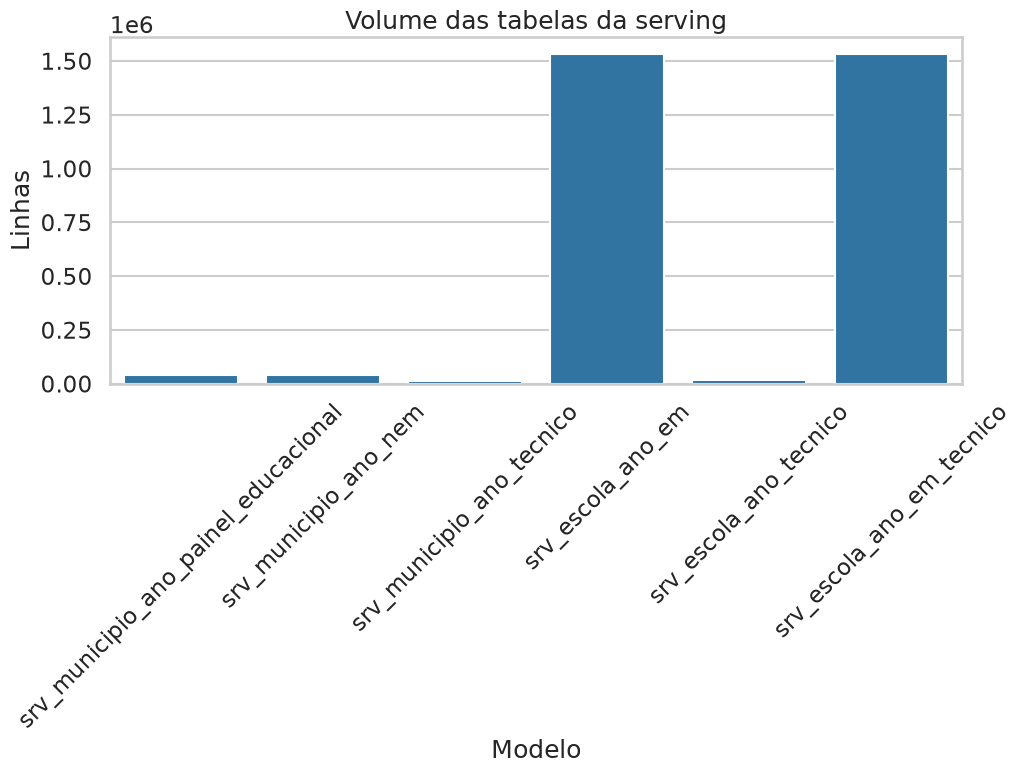

,linhas,municipios,anos,linhas_com_saeb
0,38997,5571,7,"33,098.0000"


In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=inventory, x='model_name', y='row_count', ax=ax, color='#1F77B4')
ax.set_title('Volume das tabelas da serving')
ax.set_xlabel('Modelo')
ax.set_ylabel('Linhas')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

quality = q("""
    select
        count(*) as linhas,
        count(distinct id_municipio) as municipios,
        count(distinct ano) as anos,
        sum(case when tem_saeb_no_ano_flag = 1 then 1 else 0 end) as linhas_com_saeb
    from srv_municipio_ano_painel_educacional
""")
display(quality)


,ano,periodo_nem,media_saeb_em,prop_escolas_em_com_tecnico,prop_escolas_com_tecnico,prop_mat_em_tecnico_profissional
0,2019,pre_nem,272.3270,0.0000,0.0000,0.0000
1,2020,pre_nem,272.3270,0.0000,0.0000,0.0000
2,2021,pre_nem,266.9308,0.0000,0.0000,0.0000
3,2022,implementacao_nem,266.9308,0.0000,0.0000,0.0000
4,2023,implementacao_nem,267.6300,0.0827,0.0099,0.0000
5,2024,pos_nem,267.6300,0.1068,0.0132,0.0000
6,2025,pos_nem,NaN,0.3943,0.0514,0.4990


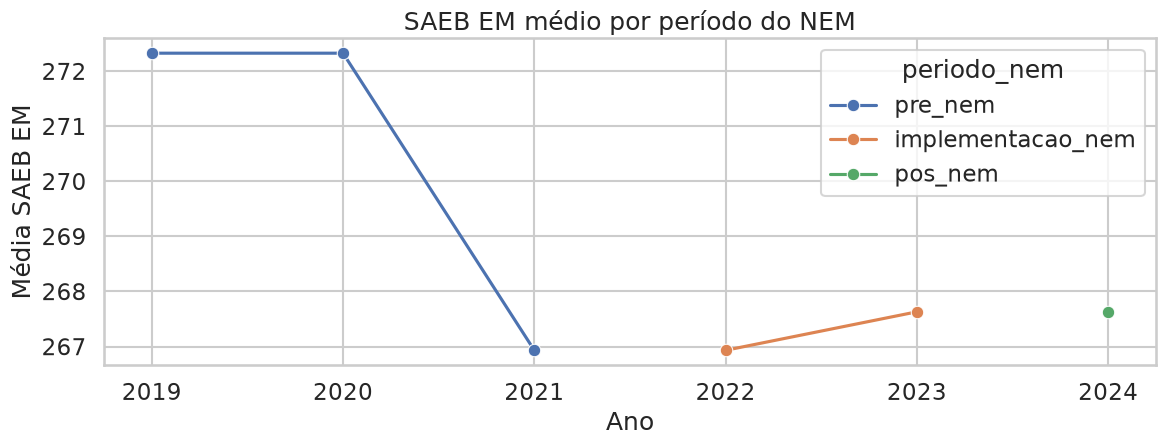

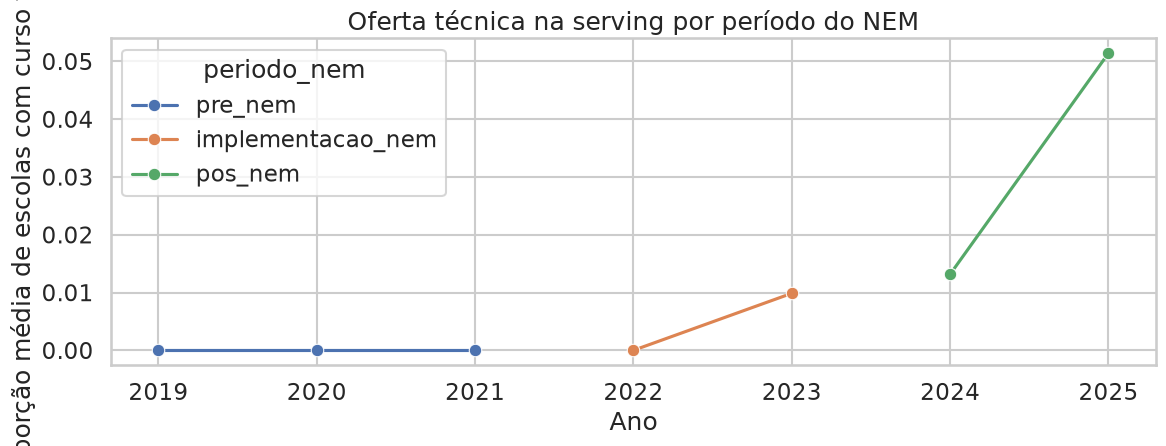

In [4]:
municipio_year = q("""
    select
        ano,
        periodo_nem,
        avg(media_12_lp_mt) as media_saeb_em,
        avg(prop_escolas_em_com_curso_tecnico) as prop_escolas_em_com_tecnico,
        avg(prop_escolas_com_curso_tecnico) as prop_escolas_com_tecnico,
        avg(prop_mat_em_tecnico_profissional) as prop_mat_em_tecnico_profissional
    from srv_municipio_ano_painel_educacional
    group by 1, 2
    order by 1, 2
""")
display(municipio_year)

fig, ax = plt.subplots(figsize=(12, 4.8))
sns.lineplot(data=municipio_year, x='ano', y='media_saeb_em', hue='periodo_nem', marker='o', ax=ax)
ax.set_title('SAEB EM médio por período do NEM')
ax.set_xlabel('Ano')
ax.set_ylabel('Média SAEB EM')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4.8))
sns.lineplot(data=municipio_year, x='ano', y='prop_escolas_com_tecnico', hue='periodo_nem', marker='o', ax=ax)
ax.set_title('Oferta técnica na serving por período do NEM')
ax.set_xlabel('Ano')
ax.set_ylabel('Proporção média de escolas com curso técnico')
plt.tight_layout()
plt.show()


,corr_tecnico_saeb,corr_alfabetizacao_saeb,corr_pib_saeb
0,NaN,0.4457,0.1754


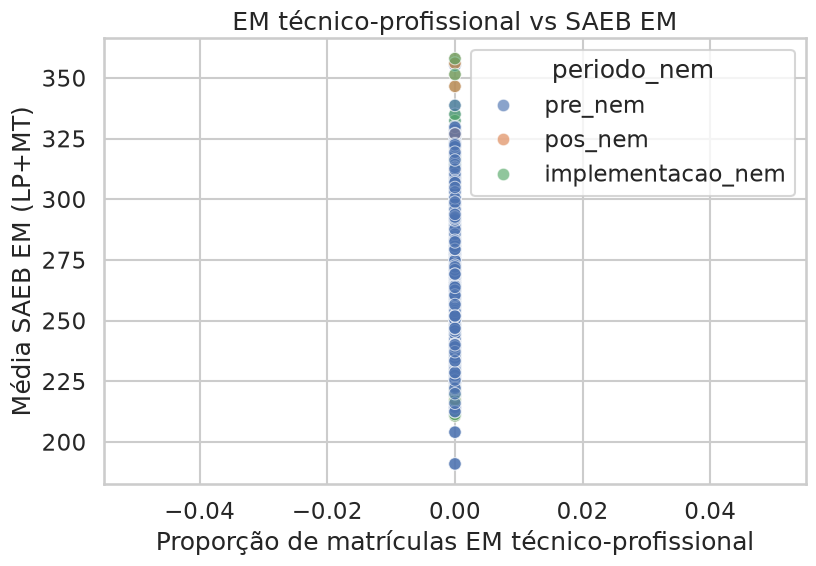

In [5]:
correlacao = q("""
    select
        corr(prop_mat_em_tecnico_profissional, media_12_lp_mt) as corr_tecnico_saeb,
        corr(taxa_alfabetizacao, media_12_lp_mt) as corr_alfabetizacao_saeb,
        corr(pib_per_capita, media_12_lp_mt) as corr_pib_saeb
    from srv_municipio_ano_painel_educacional
    where media_12_lp_mt is not null
""")
display(correlacao)

fig, ax = plt.subplots(figsize=(8.5, 6))
scatter = q("""
    select prop_mat_em_tecnico_profissional, media_12_lp_mt, periodo_nem
    from srv_municipio_ano_painel_educacional
    where prop_mat_em_tecnico_profissional is not null
      and media_12_lp_mt is not null
""")
sns.scatterplot(data=scatter, x='prop_mat_em_tecnico_profissional', y='media_12_lp_mt', hue='periodo_nem', alpha=0.65, ax=ax)
ax.set_title('EM técnico-profissional vs SAEB EM')
ax.set_xlabel('Proporção de matrículas EM técnico-profissional')
ax.set_ylabel('Média SAEB EM (LP+MT)')
plt.tight_layout()
plt.show()


,ano,escolas_em_tecnico,share_em_e_tecnico_no_mesmo_ano,share_em_e_tecnico_no_nem
0,2019,226704,0.0000,0.0000
1,2020,222475,0.0000,0.0000
2,2021,219355,0.0000,0.0000
3,2022,222969,0.0000,0.0000
4,2023,215870,0.0076,0.0009
5,2024,213901,0.0092,0.0009
6,2025,212574,0.0429,0.0383


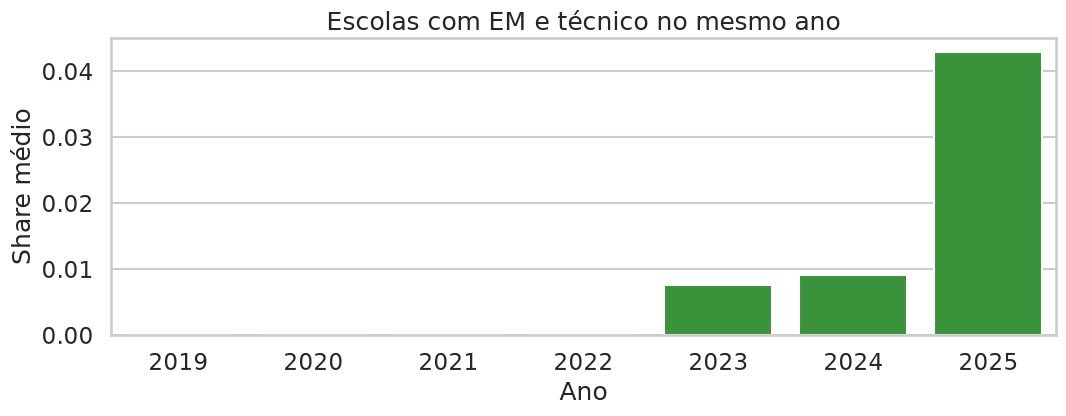

Leitura possível hoje: impacto associado ao NEM, contexto municipal, oferta técnica e comparação temporal. Abandono observado continua sem fonte direta.


In [6]:
em_tecnico = q("""
    select
        ano,
        count(*) as escolas_em_tecnico,
        avg(tem_em_e_tecnico_no_mesmo_ano) as share_em_e_tecnico_no_mesmo_ano,
        avg(tem_em_e_tecnico_no_nem) as share_em_e_tecnico_no_nem
    from srv_escola_ano_em_tecnico
    group by 1
    order by 1
""")
display(em_tecnico)

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=em_tecnico, x='ano', y='share_em_e_tecnico_no_mesmo_ano', ax=ax, color='#2CA02C')
ax.set_title('Escolas com EM e técnico no mesmo ano')
ax.set_xlabel('Ano')
ax.set_ylabel('Share médio')
plt.tight_layout()
plt.show()

print('Leitura possível hoje: impacto associado ao NEM, contexto municipal, oferta técnica e comparação temporal. Abandono observado continua sem fonte direta.')


## O que essa serving já responde

- Relação entre EM/NEM e desempenho SAEB no ciclo observado.
- Relação entre oferta técnica e estrutura escolar/municipal.
- Comparações temporais pre, durante e pós implementação do NEM.
- Articulação entre EM e curso técnico no mesmo ano e na mesma escola.

## Limite metodológico

A serving não inventa abandono, reprovação ou evasão. Se você observar redução de matrículas ou turmas, a leitura correta é de proxy analítico de fragilidade/contração da oferta, não de abandono medido diretamente.
